# 4. Process Enhancement
## Invoice-to-Payment Process Optimization — BPI Challenge 2019

*See the [README](https://github.com/JohannesKuh/invoice-to-payment-process-optimization/blob/main/README.md) for full project overview, business problem and dataset details.*

This notebook investigates the **second part of the
[BPI Challenge 2019](https://icpmconference.org/2019/icpm-2019/contests-challenges/bpi-challenge-2019/)'s
three official questions** and concentrates on Process Enhancement: what
is the throughput of the invoicing process — specifically, the time
between goods receipt, invoice receipt, and payment (clear invoice)?

*Note:* The challenge's question further asks for a technique to match
these events within a line item — i.e., if there are multiple goods
receipt messages and multiple invoices within a line item, how they are
related and which belong together. This is analyzed here using simplified
first-occurrence matching; the deeper question of matching multiple
GR/invoice messages within a line item is addressed in the planned OCPM
extension.

## 4.1 Imports & Setup
- Import libraries, mount Drive
- Load the cleaned dataset (from Notebook 1)

In [ ]:
# Install dependencies
!pip install pm4py --quiet

In [ ]:
# Imports
import pandas as pd
import pm4py
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the cleaned dataset from Notebook 1
file_path = "/content/drive/MyDrive/Colab Notebooks/Invoice-to-Payment Process Project/BPI Challenge 2019_Data/BPI_2019_cleaned.parquet"

event_log = pd.read_parquet(file_path)
print(f"Shape: {event_log.shape}")
event_log.head()

Shape: (1595603, 22)


,User,org:resource,concept:name,Cumulative net worth (EUR),time:timestamp,case:Spend area text,case:Company,case:Document Type,case:Sub spend area text,case:Purchasing Document,...,case:Item Type,case:Item Category,case:Spend classification text,case:Source,case:Name,case:GR-Based Inv. Verif.,case:Item,case:concept:name,case:Goods Receipt,event_month
0,batch_00,batch_00,SRM: Created,298.0,2018-01-02 12:53:00+00:00,CAPEX & SOCS,companyID_0000,EC Purchase order,Facility Management,2000000000,...,Standard,"3-way match, invoice before GR",NPR,sourceSystemID_0000,vendor_0000,False,00001,2000000000_00001,True,2018-01
1,batch_00,batch_00,SRM: Complete,298.0,2018-01-02 13:53:00+00:00,CAPEX & SOCS,companyID_0000,EC Purchase order,Facility Management,2000000000,...,Standard,"3-way match, invoice before GR",NPR,sourceSystemID_0000,vendor_0000,False,00001,2000000000_00001,True,2018-01
2,batch_00,batch_00,SRM: Awaiting Approval,298.0,2018-01-02 13:53:00+00:00,CAPEX & SOCS,companyID_0000,EC Purchase order,Facility Management,2000000000,...,Standard,"3-way match, invoice before GR",NPR,sourceSystemID_0000,vendor_0000,False,00001,2000000000_00001,True,2018-01
3,batch_00,batch_00,SRM: Document Completed,298.0,2018-01-02 13:53:00+00:00,CAPEX & SOCS,companyID_0000,EC Purchase order,Facility Management,2000000000,...,Standard,"3-way match, invoice before GR",NPR,sourceSystemID_0000,vendor_0000,False,00001,2000000000_00001,True,2018-01
4,batch_00,batch_00,SRM: In Transfer to Execution Syst.,298.0,2018-01-02 13:53:00+00:00,CAPEX & SOCS,companyID_0000,EC Purchase order,Facility Management,2000000000,...,Standard,"3-way match, invoice before GR",NPR,sourceSystemID_0000,vendor_0000,False,00001,2000000000_00001,True,2018-01


In [ ]:
# Preserve event_month before pm4py's formatting step potentially alters it
event_month_backup = event_log['event_month'].copy()

event_log_formatted = pm4py.format_dataframe(
    event_log,
    case_id='case:concept:name',
    activity_key='concept:name',
    timestamp_key='time:timestamp'
)

event_log_formatted['event_month'] = event_month_backup

print(event_log_formatted.shape)

(1595603, 24)


In [ ]:
# Sanity check: confirm formatting preserved data integrity
n_events = event_log_formatted.shape[0]
n_cases = event_log_formatted['case:concept:name'].nunique()
timestamps_sorted = event_log_formatted.groupby('case:concept:name')['time:timestamp'].apply(
    lambda s: s.is_monotonic_increasing
).all()

print(f"Events: {n_events:,}")
print(f"Cases: {n_cases:,}")
print(f"Timestamps sorted within each case: {timestamps_sorted}")

assert n_events == 1_595_603, "Event count changed after formatting"
assert n_cases == 251_734, "Case count changed after formatting"
assert timestamps_sorted, "Timestamps not sorted within at least one case"

print("\n4.1 formatting checks passed.")

Events: 1,595,603
Cases: 251,734
Timestamps sorted within each case: True

4.1 formatting checks passed.


## 4.2 Case-Level Throughput

### 4.2.1 Case-Starting Activity Distribution
- Distribution of first-occurring activity per case
- Cross-validation against Hüser & Heisenberger (2019)

In [ ]:
# Determine the first-occurring activity per case

first_events = (
    event_log_formatted
    .sort_values(['case:concept:name', 'time:timestamp'])
    .groupby('case:concept:name')['concept:name']
    .first()
)

print(f"first_events computed for {len(first_events):,} cases")

first_events computed for 251,734 cases


In [ ]:
# Case-starting activity distribution

assert len(first_events) == 251_734, "first_events case count doesn't match confirmed total"

starting_activity_counts = first_events.value_counts()
starting_activity_pct = (starting_activity_counts / starting_activity_counts.sum() * 100).round(2)

starting_activity_dist = pd.DataFrame({
    'case_count': starting_activity_counts,
    'pct_of_cases': starting_activity_pct
})

print(f"Total cases: {starting_activity_counts.sum():,}")
starting_activity_dist.head(10)

Total cases: 251,734


,case_count,pct_of_cases
concept:name,,
Create Purchase Order Item,200105,79.49
Create Purchase Requisition Item,46520,18.48
Vendor creates invoice,3223,1.28
SRM: Created,1375,0.55
Change Approval for Purchase Order,382,0.15
Vendor creates debit memo,105,0.04
Release Purchase Order,22,0.01
Change Currency,2,0.0


In [ ]:
# Exact count/pct for 'other', different of top 3
top3 = ['Create Purchase Order Item', 'Create Purchase Requisition Item', 'Vendor creates invoice']
other_count = starting_activity_counts[~starting_activity_counts.index.isin(top3)].sum()
other_pct = round(other_count / starting_activity_counts.sum() * 100, 2)
print(f"Other: {other_count:,} cases ({other_pct}%)")

Other: 1,886 cases (0.75%)


**Key insight — Case-starting activity distribution:**

In the cleaned dataset (1,595,603 events, 251,734 cases), the distribution of starting-activities is as follows:

* **Create Purchase Order Item:** 200,105 cases, 79.49% — clear majority of starting-activities
* **Create Purchase Requisition Item:** 46,520 cases, 18.48% — second most frequent starting-activity
* **Vendor creates invoice:** 3,223 cases, 1.28%
* **Other:** 1,886 cases, 0.75% — clear minority cases including SRM Created, Change Approval for Purchase Order, Vendor creates debit memo, Release Purchase Order and Change Currency

*Cross-validation:* These proportions closely replicate the starting-activity distribution reported by [Hüser & Heisenberger (2019)](https://icpmconference.org/2019/wp-content/uploads/sites/6/2019/07/BPI-Challenge-Student-Submission-2.pdf) on the unfiltered version of the same log (Create Purchase Order Item ≈80%, Create Purchase Requisition Item ≈18%, Vendor creates invoice ≈1.4% respectively, 251,734 cases with 1,595,923 events).

### 4.2.2 Milestone Extraction

- Extract first-occurrence timestamp per case for the three throughput milestones: "Record Goods Receipt", "Record Invoice Receipt", "Clear Invoice" (following core sequence PO Item → GR → Invoice Receipt → Clear Invoice)
- *Note:* this uses simplified first-occurrence matching as an approximation; the BPI Challenge's actual Question 2 asks for a technique to match multiple GR/invoice messages within a line item — this deeper matching is deferred to the planned OCPM extension

In [ ]:
# First-occurrence timestamp per case for each of the three milestone activities

milestones = ['Record Goods Receipt', 'Record Invoice Receipt', 'Clear Invoice']

milestone_events = event_log_formatted[event_log_formatted['concept:name'].isin(milestones)]

first_occurrence = (
    milestone_events
    .sort_values(['case:concept:name', 'time:timestamp'])
    .groupby(['case:concept:name', 'concept:name'])['time:timestamp']
    .first()
    .unstack('concept:name')
)

print(first_occurrence.shape)
first_occurrence.head()

(235864, 3)


concept:name,Clear Invoice,Record Goods Receipt,Record Invoice Receipt
case:concept:name,,,
2000000000_00001,2018-03-29 13:06:00+00:00,2018-03-06 06:44:00+00:00,2018-03-06 07:53:00+00:00
2000000001_00001,2018-03-08 12:21:00+00:00,2018-01-16 12:09:00+00:00,2018-01-16 14:44:00+00:00
2000000002_00001,2018-08-16 13:03:00+00:00,2018-02-06 14:53:00+00:00,2018-08-16 10:41:00+00:00
2000000003_00001,2018-03-08 12:21:00+00:00,2018-01-12 13:14:00+00:00,2018-02-12 15:58:00+00:00
2000000003_00002,2018-03-08 12:21:00+00:00,2018-01-12 13:14:00+00:00,2018-02-12 15:58:00+00:00


In [ ]:
# Check how many cases are missing each milestone

# Reindex to the FULL case list so cases with zero milestone activities
# appear as all-NaN rows, rather than being silently absent
all_cases = event_log_formatted['case:concept:name'].unique()
first_occurrence_full = first_occurrence.reindex(all_cases)

print(first_occurrence_full.shape)

missing_counts = first_occurrence_full.isna().sum()
missing_pct = (missing_counts / len(first_occurrence_full) * 100).round(2)
pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})

(251734, 3)


,missing_count,missing_pct
concept:name,,
Clear Invoice,68057,27.04
Record Goods Receipt,17255,6.85
Record Invoice Receipt,40355,16.03


In [ ]:
# What do the cases with ZERO milestone activities actually contain?

zero_milestone_cases = set(all_cases) - set(first_occurrence.index)
print(f"Zero-milestone cases: {len(zero_milestone_cases):,}")

subset = event_log_formatted[event_log_formatted['case:concept:name'].isin(zero_milestone_cases)]

print("\nEvents per case (zero-milestone subset):")
print(subset.groupby('case:concept:name').size().describe())

last_activity = (
    subset
    .sort_values(['case:concept:name', 'time:timestamp'])
    .groupby('case:concept:name')['concept:name']
    .last()
)

# Counts + percentages together, so the Key Insight numbers can be read straight off this table
last_activity_counts = last_activity.value_counts()
last_activity_pct = (last_activity_counts / last_activity_counts.sum() * 100).round(2)

last_activity_dist = pd.DataFrame({
    'case_count': last_activity_counts,
    'pct_of_cases': last_activity_pct
})

print("\nMost common last activity in these cases:")
print(last_activity_dist.head(10))

Zero-milestone cases: 15,870

Events per case (zero-milestone subset):
count    15870.000000
mean         2.309074
std          1.205596
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         25.000000
dtype: float64

Most common last activity in these cases:
                                    case_count  pct_of_cases
concept:name                                                
Delete Purchase Order Item                8024         50.56
Create Purchase Order Item                4447         28.02
Change Approval for Purchase Order        1147          7.23
Cancel Invoice Receipt                     445           2.8
Change Price                               387          2.44
Change Delivery Indicator                  367          2.31
Change Quantity                            364          2.29
Receive Order Confirmation                 223          1.41
Cancel Goods Receipt                       201          1.27
Block Purchase Order Ite

In [ ]:
# Test whether zero-milestone cases cluster near the log's end date (truncation artifact)
# vs. spread across the full observed range (genuine termination)

log_min_date = event_log_formatted['time:timestamp'].min()
log_max_date = event_log_formatted['time:timestamp'].max()
print(f"Log date range: {log_min_date.date()} to {log_max_date.date()}")

last_event_time = (
    subset
    .sort_values(['case:concept:name', 'time:timestamp'])
    .groupby('case:concept:name')['time:timestamp']
    .last()
)

days_before_cutoff = (log_max_date - last_event_time).dt.days
print(days_before_cutoff.describe())

# Month-by-month distribution, to visualize the pattern rather than rely on one statistic
monthly_dist = last_event_time.dt.to_period('M').value_counts().sort_index()
print(monthly_dist)

Log date range: 2018-01-01 to 2019-12-05
count    15870.000000
mean       464.385633
std        111.636741
min        322.000000
25%        363.000000
50%        435.000000
75%        559.000000
max        702.000000
Name: time:timestamp, dtype: float64
time:timestamp
2018-01     856
2018-02     662
2018-03    1073
2018-04     733
2018-05     756
2018-06     736
2018-07     808
2018-08     871
2018-09    1508
2018-10    1484
2018-11    1640
2018-12    4133
2019-01     610
Freq: M, Name: count, dtype: int64


/tmp/ipykernel_4564/3993721139.py:19: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_dist = last_event_time.dt.to_period('M').value_counts().sort_index()


In [ ]:
# Dec 2018 accounts for 26% of all zero-milestone cases — check what's driving it

dec_2018_cases = last_event_time[last_event_time.dt.to_period('M') == '2018-12'].index
dec_2018_last_activity = last_activity.loc[dec_2018_cases]
print(dec_2018_last_activity.value_counts())

concept:name
Create Purchase Order Item             2507
Change Approval for Purchase Order      523
Delete Purchase Order Item              377
Change Price                            272
Change Quantity                         145
Receive Order Confirmation              100
Cancel Goods Receipt                     85
Cancel Invoice Receipt                   55
Change Delivery Indicator                47
SRM: Change was Transmitted              13
SRM: Deleted                              7
SRM: In Transfer to Execution Syst.       1
Block Purchase Order Item                 1
Name: count, dtype: Int64


/tmp/ipykernel_4564/3580950689.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  dec_2018_cases = last_event_time[last_event_time.dt.to_period('M') == '2018-12'].index


**Key insight — Zero-milestone cases:**

The dataset contains 15,870 cases without a milestone activity ("Record Goods
Receipt", "Record Invoice Receipt", "Clear Invoice"). These zero-milestone
cases range from very short to relatively long (1 to 25 events), though a
median of 2 events shows that half of these cases are minimal. Analyzing the
end of these cases, the last activities are:

- **Delete Purchase Order Item:** 8,024 cases, 50.56% — roughly half of all
  zero-milestone cases end with the purchase order item being deleted from
  the system
- **Create Purchase Order Item:** 4,447 cases, 28.02% — around a quarter of
  all cases missing a milestone end with the creation of a purchase order
  item, with no further activity recorded
- **Change Approval for Purchase Order:** 1,147 cases, 7.23% — a smaller but
  still notable share end on an approval-change event
- **Other:** 2,252 cases, 14.19% — remaining zero-milestone cases include
  other final steps such as "Cancel Invoice Receipt" or "Change Price" (445
  and 387 cases respectively)

*Note:* these cases were checked against the "snapshots challenge" (van der
Aalst, via [Bernard & Andritsos, 2020](https://doi.org/10.1007/978-3-030-49418-6_10))
— the possibility that they represent traces truncated by the log's fixed
extraction window rather than genuinely completed/abandoned processes. This
was ruled out: a month-by-month breakdown of last-event dates shows no cases
at all in the log's final 11 months (Feb–Dec 2019), with the most recent case
ending 322 days before the log's actual end (2019-12-05) — the opposite of
what a truncation artifact would look like. This supports interpreting these
as genuinely terminated cases rather than a data-window artifact.

A secondary pattern was found instead: December 2018 alone accounts for 26%
of all zero-milestone cases (4,133 of 15,870), with "Create Purchase Order
Item" as the dominant last activity (2,507 of 4,133 December cases, 60.7%) —
consistent with, but not confirmed as, a year-end purchasing pattern where PO
items created near the fiscal year's end received no further processing. This
is noted as an open observation for potential follow-up analysis.

### 4.2.3 Throughput Calculation

- Compute time deltas (in days) between milestone pairs: GR→IR, IR→Clear, GR→Clear
- *Note:* deltas are signed rather than absolute — a negative GR→IR value means "Record Invoice Receipt" occurred before "Record Goods Receipt" for that case, which is expected behavior for the "3-way match, invoice before GR" category (see `case:Item Category`, Notebook 2). Signed values are preserved here so this directionality remains visible for segmented analysis in 4.5, rather than being collapsed away.

In [ ]:
# Compute throughput deltas (in days) between milestone pairs, using first_occurrence_full
# so all 251,734 cases are represented (NaN where a milestone is missing)

throughput = pd.DataFrame(index=first_occurrence_full.index)

throughput['gr_to_ir_days'] = (
    first_occurrence_full['Record Invoice Receipt'] - first_occurrence_full['Record Goods Receipt']
).dt.total_seconds() / 86400

throughput['ir_to_clear_days'] = (
    first_occurrence_full['Clear Invoice'] - first_occurrence_full['Record Invoice Receipt']
).dt.total_seconds() / 86400

throughput['gr_to_clear_days'] = (
    first_occurrence_full['Clear Invoice'] - first_occurrence_full['Record Goods Receipt']
).dt.total_seconds() / 86400

print(throughput.shape)
throughput.describe()

(251734, 3)


,gr_to_ir_days,ir_to_clear_days,gr_to_clear_days
count,210370.000000,183293.000000,182808.000000
mean,18.716408,48.147858,65.758787
std,27.047983,31.465439,30.557396
min,-202.796528,-210.070139,-161.959028
25%,2.706250,22.131944,44.678299
50%,9.136806,42.051389,63.003472
75%,26.765278,70.151389,85.762500
max,337.945139,341.939583,345.220139


In [ ]:
# How many cases have implausibly large negative deltas (possible first-occurrence
# mismatch artifacts, e.g. from multiple invoice cycles)?

extreme_threshold = -30  # days; adjust after inspecting distribution

for col in ['gr_to_ir_days', 'ir_to_clear_days', 'gr_to_clear_days']:
    n_extreme = (throughput[col] < extreme_threshold).sum()
    print(f"{col}: {n_extreme:,} cases below {extreme_threshold} days")

gr_to_ir_days: 209 cases below -30 days
ir_to_clear_days: 16 cases below -30 days
gr_to_clear_days: 38 cases below -30 days


**Key insight — Overall throughput times:**

Across all cases with a valid delta, median throughput is:

- **GR → Invoice Receipt:** 9.14 days (n = 210,370)
- **Invoice Receipt → Clear Invoice:** 42.05 days (n = 183,293)
- **GR → Clear Invoice (end-to-end):** 63.00 days (n = 182,808)

The **primary driver of end-to-end throughput is Invoice Receipt → Clear Invoice** (42.05 days) as it represents roughly two-thirds of the end-to-end median (42.05 / 63.00 ≈ 67%), making it the primary driver of overall throughput. The three medians above do not sum cleanly (9.14 + 42.05 = 51.19 ≠ 63.00), since they are computed over a different, only partially overlapping case population (n = 210,370 / 183,293 / 182,808 respectively) — medians are not additive across different populations and should be read as an independent statistic.

*Note:* Median is used as the primary statistic, given the right-skewed distributions (e.g. `ir_to_clear_days` ranges up to 341.94 days, pulling the mean to 48.15 days vs. a median of 42.05). Separately, a small number of cases (0.01–0.10%) show implausible negative deltas beyond -30 days (209 for GR→IR, 16 for IR→Clear, 38 for GR→Clear), likely artifacts of first-occurrence matching across multiple invoice/GR cycles rather than genuine process behavior — see the 4.2.2 note on simplified matching.

*Cross-validation:* The mean end-to-end throughput (GR → Clear Invoice) in the
cleaned dataset is 65.76 days, closely matching the ~70-day average reported
by [Hüser & Heisenberger, 2019](https://icpmconference.org/2019/wp-content/uploads/sites/6/2019/07/BPI-Challenge-Student-Submission-2.pdf)
for the full log. This is another independent cross-validation point
(alongside the case-starting activity distribution in 4.2.1), further supporting the structural integrity of the cleaned event log.

In [ ]:
# How many cases have a negative GR→IR delta (i.e. invoice recorded before goods)?
n_negative_gr_ir = (throughput['gr_to_ir_days'] < 0).sum()
n_valid_gr_ir = throughput['gr_to_ir_days'].notna().sum()

print(f"Cases with GR→IR delta computed: {n_valid_gr_ir:,}")
print(f"Of those, negative (IR before GR): {n_negative_gr_ir:,} ({n_negative_gr_ir / n_valid_gr_ir * 100:.2f}%)")

Cases with GR→IR delta computed: 210,370
Of those, negative (IR before GR): 16,356 (7.77%)


In [ ]:
# Segment negative GR→IR deltas by case:Item Category for a fair comparison
# against Hüser & Heisenberger's Model B (90%/10% split, invoice-before-GR sublog only)

case_category = event_log_formatted.groupby('case:concept:name')['case:Item Category'].first()

throughput_with_cat = throughput.join(case_category)

negative_by_category = (
    throughput_with_cat[throughput_with_cat['gr_to_ir_days'].notna()]
    .assign(is_negative=lambda df: df['gr_to_ir_days'] < 0)
    .groupby('case:Item Category')['is_negative']
    .agg(['sum', 'count'])
)
negative_by_category['pct_negative'] = (negative_by_category['sum'] / negative_by_category['count'] * 100).round(2)
negative_by_category

,sum,count,pct_negative
case:Item Category,,,
"3-way match, invoice after GR",0,11128,0.00
"3-way match, invoice before GR",16356,199242,8.21


In [ ]:
# Confirm the 2 missing categories are absent because they structurally can't have GR+IR both present

category_total = negative_by_category['count'].sum()
valid_gr_ir = throughput['gr_to_ir_days'].notna().sum()

print(f"Total valid GR→IR deltas across shown categories: {category_total:,}")
print(f"Matches earlier valid count ({valid_gr_ir:,}): {category_total == valid_gr_ir}")

Total valid GR→IR deltas across shown categories: 210,370
Matches earlier valid count (210,370): True


**Key insight — GR/IR ordering:**

Segmenting the GR→IR delta by `case:Item Category` reveals a clean split:

- In the category **"3-way match, invoice after GR"** (11,128 cases), 0.00% show a negative delta — goods receipt precedes invoice receipt in every case, with no exceptions
- Within **"3-way match, invoice before GR"** (199,242 cases), 8.21% show a
  negative delta (invoice receipt before goods receipt) — this finding should be
further investigated, as this process variation may indicate a conformance issue

*Cross-validation:* The last finding almost matches the ~10% reversal rate
reported by [Hüser & Heisenberger, 2019](https://icpmconference.org/2019/wp-content/uploads/sites/6/2019/07/BPI-Challenge-Student-Submission-2.pdf)
for the same sublog. This is a second independent cross-validation point
(alongside the case-starting activity distribution in 4.2.1) indicating that
the cleaned event log is structurally correct.

### 4.2.4 Throughput Distribution

- Visualize the distribution of each throughput delta (GR→IR, IR→Clear, GR→Clear)
- Median marked to make the right-skew visible alongside the summary statistics from 4.2.3

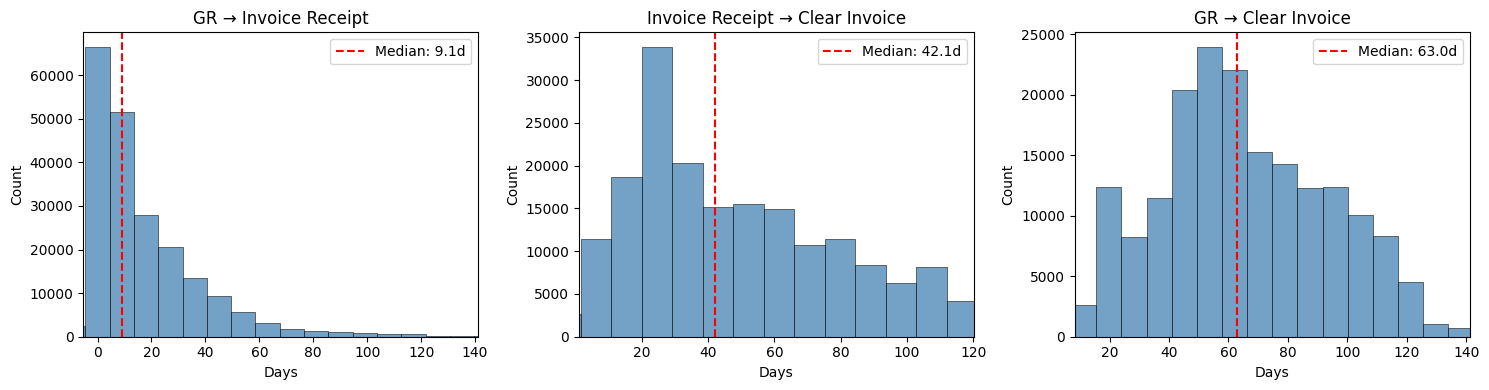

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

deltas = ['gr_to_ir_days', 'ir_to_clear_days', 'gr_to_clear_days']
titles = ['GR → Invoice Receipt', 'Invoice Receipt → Clear Invoice', 'GR → Clear Invoice']

for ax, col, title in zip(axes, deltas, titles):
    data = throughput[col].dropna()
    median_val = data.median()

    # Clip x-axis to 1st-99th percentile so a few extreme outliers
    # don't compress the main distribution into an unreadable sliver
    lower, upper = data.quantile([0.01, 0.99])

    sns.histplot(data, bins=60, ax=ax, color='steelblue')
    ax.axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val:.1f}d')
    ax.set_xlim(lower, upper)
    ax.set_title(title)
    ax.set_xlabel('Days')
    ax.legend()

plt.tight_layout()
plt.show()

**Key insight — Throughput Distribution:**

* The GR→IR and GR→Clear distributions show the expected single-peaked,
  right-skewed shape typical of process throughput times
* The IR→Clear distribution, however, shows a secondary peak between 100–120
  days alongside its main peak around 20–30 days — a pattern consistent with
  two or more distinct sub-populations being mixed in the aggregate

*Note:* The second finding is investigated further in 4.5 (Segmented
Enhancement), where throughput is broken down by `case:Item Category`,
vendor, and company.

## 4.3 Activity-Level Bottleneck Analysis

- Compute duration between consecutive activities within each case
- Identify the longest average transitions across the full log — i.e. bottlenecks
- Approach inspired by viadee's funnel-chart style bottleneck visualization (referenced in Project 1's README)

In [ ]:
# Sort once, then use shift() within each case to pair each event with the NEXT event in that case
event_log_sorted = event_log_formatted.sort_values(['case:concept:name', 'time:timestamp']).copy()

event_log_sorted['next_activity'] = event_log_sorted.groupby('case:concept:name')['concept:name'].shift(-1)
event_log_sorted['next_timestamp'] = event_log_sorted.groupby('case:concept:name')['time:timestamp'].shift(-1)

# Duration to next activity, in days (NaN for each case's final event, which has no "next")
event_log_sorted['duration_to_next_days'] = (
    event_log_sorted['next_timestamp'] - event_log_sorted['time:timestamp']
).dt.total_seconds() / 86400

print(event_log_sorted[['concept:name', 'next_activity', 'duration_to_next_days']].head(10))

                          concept:name                        next_activity  \
0                         SRM: Created                        SRM: Complete   
1                        SRM: Complete               SRM: Awaiting Approval   
2               SRM: Awaiting Approval              SRM: Document Completed   
3              SRM: Document Completed  SRM: In Transfer to Execution Syst.   
4  SRM: In Transfer to Execution Syst.                         SRM: Ordered   
5                         SRM: Ordered          SRM: Change was Transmitted   
6          SRM: Change was Transmitted           Create Purchase Order Item   
7           Create Purchase Order Item               Vendor creates invoice   
8               Vendor creates invoice                 Record Goods Receipt   
9                 Record Goods Receipt               Record Invoice Receipt   

   duration_to_next_days  
0               0.041667  
1               0.000000  
2               0.000000  
3               0.0000

In [ ]:
# Step 1: find which cases contain at least one SRM event (same as before)
srm_cases = event_log_sorted.loc[
    event_log_sorted['concept:name'].str.startswith('SRM:'), 'case:concept:name'
].unique()

print(f"SRM cases identified: {len(srm_cases):,}")

# Step 2: find the row labels (index) of every row belonging to those SRM cases
rows_to_drop = event_log_sorted[event_log_sorted['case:concept:name'].isin(srm_cases)].index

# Step 3: drop those rows directly
event_log_p2p = event_log_sorted.drop(index=rows_to_drop)

print(f"Remaining events (non-SRM): {len(event_log_p2p):,}")
print(f"Remaining cases (non-SRM): {event_log_p2p['case:concept:name'].nunique():,}")

SRM cases identified: 1,440
Remaining events (non-SRM): 1,573,261
Remaining cases (non-SRM): 250,294


In [ ]:
# Aggregate transition durations by (from_activity, to_activity) pair

transition_stats = (
    event_log_p2p
    .dropna(subset=['next_activity'])
    .groupby(['concept:name', 'next_activity'])['duration_to_next_days']
    .agg(['count', 'median', 'mean'])
    .round(2)
    .sort_values('median', ascending=False)
)

print(f"Total distinct transition pairs: {len(transition_stats)}")
transition_stats.head(20)

Total distinct transition pairs: 383


,,count,median,mean
concept:name,next_activity,,,
Change Storage Location,Block Purchase Order Item,1,203.18,203.18
Cancel Goods Receipt,Cancel Invoice Receipt,300,182.23,129.55
Change Approval for Purchase Order,Block Purchase Order Item,107,168.69,163.37
Change Currency,Create Purchase Order Item,2,121.56,121.56
Vendor creates debit memo,Create Purchase Requisition Item,4,111.00,113.51
Change Currency,Change Quantity,1,105.24,105.24
Change Approval for Purchase Order,Cancel Invoice Receipt,2,104.08,104.08
Clear Invoice,Cancel Invoice Receipt,2060,85.21,84.55
Record Invoice Receipt,Block Purchase Order Item,34,84.33,58.45


In [ ]:
# Check the distribution of transition-pair counts before choosing a minimum threshold

print(transition_stats['count'].describe())
print()
print("Number of transition pairs remaining, by minimum count threshold:")
for threshold in [10, 30, 50, 100, 500]:
    n_pairs = (transition_stats['count'] >= threshold).sum()
    print(f"  count >= {threshold}: {n_pairs} pairs remain")

count       383.000000
mean       3454.221932
std       16271.547740
min           1.000000
25%           5.500000
50%          44.000000
75%         323.000000
max      139105.000000
Name: count, dtype: float64

Number of transition pairs remaining, by minimum count threshold:
  count >= 10: 261 pairs remain
  count >= 30: 213 pairs remain
  count >= 50: 186 pairs remain
  count >= 100: 152 pairs remain
  count >= 500: 84 pairs remain


In [ ]:
# Apply minimum-count threshold to exclude statistically unstable rare transitions,
# then show the top 20 genuine bottlenecks by median duration

MIN_TRANSITION_COUNT = 50

bottlenecks = transition_stats[transition_stats['count'] >= MIN_TRANSITION_COUNT].sort_values('median', ascending=False)

print(f"Transition pairs meeting count >= {MIN_TRANSITION_COUNT}: {len(bottlenecks)} (of {len(transition_stats)} total)")
bottlenecks.head(20)

Transition pairs meeting count >= 50: 186 (of 383 total)


,,count,median,mean
concept:name,next_activity,,,
Cancel Goods Receipt,Cancel Invoice Receipt,300,182.23,129.55
Change Approval for Purchase Order,Block Purchase Order Item,107,168.69,163.37
Clear Invoice,Cancel Invoice Receipt,2060,85.21,84.55
Change Approval for Purchase Order,Change Quantity,319,51.85,51.14
Change Quantity,Clear Invoice,157,51.00,51.14
Change Approval for Purchase Order,Clear Invoice,120,44.78,40.74
Record Goods Receipt,Cancel Invoice Receipt,355,41.95,46.24
Change Delivery Indicator,Clear Invoice,265,41.07,43.78
Record Invoice Receipt,Clear Invoice,133595,36.19,43.97


In [ ]:
# Top transitions by raw occurrence count, unfiltered — frequency itself is
# already a stable count with no minimum-threshold concern

top_by_occurrence = transition_stats.sort_values('count', ascending=False)

print("Top 20 transitions by occurrence count:")
top_by_occurrence.head(20)

Top 20 transitions by occurrence count:


,,count,median,mean
concept:name,next_activity,,,
Record Service Entry Sheet,Record Service Entry Sheet,139105,0.00,0.00
Record Invoice Receipt,Clear Invoice,133595,36.19,43.97
Record Goods Receipt,Record Invoice Receipt,111435,12.69,21.57
Vendor creates invoice,Record Goods Receipt,109143,1.42,2.38
Create Purchase Order Item,Vendor creates invoice,102457,6.52,11.98
Vendor creates invoice,Record Invoice Receipt,94926,4.66,12.54
Record Goods Receipt,Vendor creates invoice,80490,0.62,3.29
Create Purchase Order Item,Record Goods Receipt,77033,12.78,15.39
Record Goods Receipt,Record Goods Receipt,54274,0.00,0.28


In [ ]:
# Build combined summary table across all 5 themes, pulling directly from
# transition_stats to keep numbers traceable rather than retyped by hand

theme_map = {
    ('Record Service Entry Sheet', 'Record Service Entry Sheet'): 'Repetitive activities (self-loop)',
    ('Record Goods Receipt', 'Record Goods Receipt'): 'Repetitive activities (self-loop)',

    ('Record Invoice Receipt', 'Clear Invoice'): 'Core process flow',
    ('Record Goods Receipt', 'Record Invoice Receipt'): 'Core process flow',
    ('Vendor creates invoice', 'Record Goods Receipt'): 'Core process flow',
    ('Create Purchase Order Item', 'Vendor creates invoice'): 'Core process flow',
    ('Vendor creates invoice', 'Record Invoice Receipt'): 'Core process flow',
    ('Record Goods Receipt', 'Vendor creates invoice'): 'Core process flow',
    ('Create Purchase Order Item', 'Record Goods Receipt'): 'Core process flow',

    ('Record Invoice Receipt', 'Remove Payment Block'): 'Payment-block sub-flow',
    ('Remove Payment Block', 'Clear Invoice'): 'Payment-block sub-flow',

    ('Cancel Goods Receipt', 'Cancel Invoice Receipt'): 'Deviation cluster',
    ('Clear Invoice', 'Cancel Invoice Receipt'): 'Deviation cluster',
    ('Record Goods Receipt', 'Cancel Invoice Receipt'): 'Deviation cluster',

    ('Change Approval for Purchase Order', 'Block Purchase Order Item'): 'Approval-related delays',
}

summary_table = transition_stats.loc[list(theme_map.keys())].copy()
summary_table['theme'] = [theme_map[idx] for idx in summary_table.index]
summary_table = summary_table[['theme', 'count', 'median', 'mean']].sort_values(
    ['theme', 'median'], ascending=[True, False]
)

summary_table

theme  \
concept:name                       next_activity                                                   
Change Approval for Purchase Order Block Purchase Order Item             Approval-related delays   
Record Invoice Receipt             Clear Invoice                               Core process flow   
Create Purchase Order Item         Record Goods Receipt                        Core process flow   
Record Goods Receipt               Record Invoice Receipt                      Core process flow   
Create Purchase Order Item         Vendor creates invoice                      Core process flow   
Vendor creates invoice             Record Invoice Receipt                      Core process flow   
                                   Record Goods Receipt                        Core process flow   
Record Goods Receipt               Vendor creates invoice                      Core process flow   
Cancel Goods Receipt               Cancel Invoice Receipt                      Deviation cluster   
Clear Invoice                      Cancel Invoice Receipt                      Deviation cluster   
Record Goods Receipt               Cancel Invoice Receipt                      Deviation cluster   
Remove Payment Block               Clear Invoice                          Payment-block sub-flow   
Record Invoice Receipt             Remove Payment Block                   Payment-block sub-flow   
Record Service Entry Sheet         Record Service Entry Sheet  Repetitive activities (self-loop)   
Record Goods Receipt               Record Goods Receipt        Repetitive activities (self-loop)   

                                                                count  median  \
concept:name                       next_activity                                
Change Approval for Purchase Order Block Purchase Order Item      107  168.69   
Record Invoice Receipt             Clear Invoice               133595   36.19   
Create Purchase Order Item         Record Goods Receipt         77033   12.78   
Record Goods Receipt               Record Invoice Receipt      111435   12.69   
Create Purchase Order Item         Vendor creates invoice      102457    6.52   
Vendor creates invoice             Record Invoice Receipt       94926    4.66   
                                   Record Goods Receipt        109143    1.42   
Record Goods Receipt               Vendor creates invoice       80490    0.62   
Cancel Goods Receipt               Cancel Invoice Receipt         300  182.23   
Clear Invoice                      Cancel Invoice Receipt        2060   85.21   
Record Goods Receipt               Cancel Invoice Receipt         355   41.95   
Remove Payment Block               Clear Invoice                49309   26.39   
Record Invoice Receipt             Remove Payment Block         37588    8.04   
Record Service Entry Sheet         Record Service Entry Sheet  139105    0.00   
Record Goods Receipt               Record Goods Receipt         54274    0.00   

                                                                 mean  
concept:name                       next_activity                       
Change Approval for Purchase Order Block Purchase Order Item   163.37  
Record Invoice Receipt             Clear Invoice                43.97  
Create Purchase Order Item         Record Goods Receipt         15.39  
Record Goods Receipt               Record Invoice Receipt       21.57  
Create Purchase Order Item         Vendor creates invoice       11.98  
Vendor creates invoice             Record Invoice Receipt       12.54  
                                   Record Goods Receipt          2.38  
Record Goods Receipt               Vendor creates invoice        3.29  
Cancel Goods Receipt               Cancel Invoice Receipt      129.55  
Clear Invoice                      Cancel Invoice Receipt       84.55  
Record Goods Receipt               Cancel Invoice Receipt       46.24  
Remove Payment Block               Clear Invoice                36.39  
Reco

*Note:* The blank cell under `concept:name` for the "Vendor creates invoice"
→ "Record Goods Receipt" row is not missing data — pandas omits repeated
index values in consecutive rows of a multi-index for readability (standard
display behavior).

**Key insight — Activity-level bottlenecks:**

Excluding SRM cases (see 4.3 setup), the following **five patterns** emerge when
analyzing the top 20 transitions by occurrence and the longest-duration
transitions among pairs occurring at least 50 times (186 of 383 distinct transition pairs):

- **Approval-related delays:** "Change Approval for Purchase Order" → "Block
  Purchase Order Item" (107 occurrences, median 168.69 days) is the
  second-longest median duration overall, though a comparatively low-volume
  pattern

- **Core process flow:** the dominant genuine bottleneck by volume is
  "Record Invoice Receipt" → "Clear Invoice" (133,595 occurrences, median
  36.19 days), representing the immediate next-step gap when Clear Invoice
  directly follows Invoice Receipt (a narrower measure than the
  first-occurrence-based `ir_to_clear_days` throughput in 4.2.3, median 42.05
  days, which allows other activities in between); the remaining core-flow
  transitions (PO item creation through GR/invoice creation) all show shorter
  median durations (0.62–12.78 days), consistent with effective process
  automation

- **Deviation cluster:** three transitions describe an invoice receipt being
  cancelled after other steps already progressed, complementing the deviation
  and severity analysis in Notebook 3:
  - the highest-volume is "Clear Invoice" → "Cancel Invoice Receipt" (2,060
    occurrences, median 85.21 days) — an invoice cancelled after already
    being cleared
  - the longest median is "Cancel Goods Receipt" → "Cancel Invoice Receipt"
    (300 occurrences, median 182.23 days)

- **Payment-block sub-flow:** a substantial secondary pathway — "Remove
  Payment Block" → "Clear Invoice" (49,309 occurrences, median 26.39 days)
  and "Record Invoice Receipt" → "Remove Payment Block" (37,588 occurrences,
  median 8.04 days) — affects a meaningful share of payment-related cases and
  adds materially to end-to-end throughput

- **Repetitive activities (self-loop):** "Record Service Entry Sheet" →
  itself is the single most frequent transition in the entire log (139,105
  occurrences, median 0.00 days), with "Record Goods Receipt" → itself close
  behind (54,274 occurrences) — confirming the high-multiplicity pattern
  first observed in Notebook 1 for some cases (e.g. case `4507013227_00001`,
  509 events, many repeated "Record Service Entry Sheet" events sharing
  identical timestamps) and reinforcing the planned OCPM extension

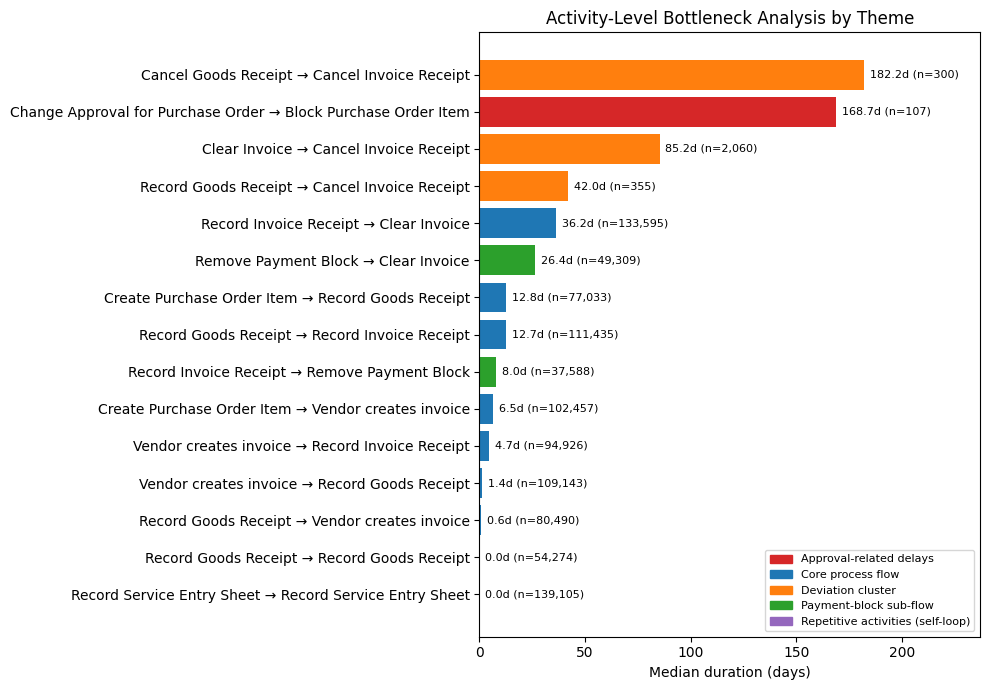

In [ ]:
# Visualization of Activity-Level Bottleneck Analysis by Theme

fig, ax = plt.subplots(figsize=(10, 7))

plot_data = summary_table.reset_index().sort_values('median', ascending=True)
plot_data['label'] = plot_data['concept:name'] + ' → ' + plot_data['next_activity']

theme_colors = {
    'Approval-related delays': '#d62728',
    'Core process flow': '#1f77b4',
    'Deviation cluster': '#ff7f0e',
    'Payment-block sub-flow': '#2ca02c',
    'Repetitive activities (self-loop)': '#9467bd',
}
colors = plot_data['theme'].map(theme_colors)

bars = ax.barh(plot_data['label'], plot_data['median'], color=colors)

# Add count + median labels just past the end of each bar
max_median = plot_data['median'].max()
offset = max_median * 0.015  # small fixed gap so labels don't touch the bars

for bar, count, median in zip(bars, plot_data['count'], plot_data['median']):
    width = bar.get_width()
    ax.text(
        width + offset,
        bar.get_y() + bar.get_height() / 2,
        f'{median:.1f}d (n={count:,})',
        va='center', fontsize=8
    )

ax.set_xlabel('Median duration (days)')
ax.set_title('Activity-Level Bottleneck Analysis by Theme')

# Extend x-axis so the longest labels have room and aren't clipped
ax.set_xlim(0, max_median * 1.3)

handles = [plt.Rectangle((0,0),1,1, color=c) for c in theme_colors.values()]
ax.legend(handles, theme_colors.keys(), loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

## 4.4 Variant Analysis

### 4.4.1 Dominant Category Deep-Dive
- Variant analysis of the dominant flow category ("3-way match, invoice before
  GR", 221,010 cases, 87.80% of all cases) — relocated from Notebook 2
- Variant frequency and long-tail distribution

In [ ]:
# Filter to the dominant flow category (87.80% of all cases) — variant analysis
# here reflects this category only, not the full dataset
main_flow = event_log_formatted[event_log_formatted['case:Item Category'] == '3-way match, invoice before GR']

# Each case's variant = the full ordered sequence of its activities
variant_counts = main_flow.groupby('case:concept:name')['concept:name'].apply(tuple).value_counts()

print(f"Cases in dominant category: {main_flow['case:concept:name'].nunique():,}")
print(f"Number of unique variants: {len(variant_counts):,}")
print(variant_counts.head(5))

Cases in dominant category: 221,010
Number of unique variants: 7,835
concept:name
(Create Purchase Order Item, Vendor creates invoice, Record Goods Receipt, Record Invoice Receipt, Clear Invoice)                                47959
(Create Purchase Order Item, Record Goods Receipt, Vendor creates invoice, Record Invoice Receipt, Clear Invoice)                                29411
(Create Purchase Order Item, Vendor creates invoice, Record Goods Receipt, Record Invoice Receipt, Remove Payment Block, Clear Invoice)          10854
(Create Purchase Order Item, Receive Order Confirmation, Record Goods Receipt, Vendor creates invoice, Record Invoice Receipt, Clear Invoice)     9694
(Create Purchase Order Item, Vendor creates invoice, Record Invoice Receipt, Record Goods Receipt, Remove Payment Block, Clear Invoice)           8835
Name: count, dtype: int64


In [ ]:
# What share of cases (within this category) are covered by just the top 5 variants?

top5_coverage = variant_counts.head(5).sum() / len(main_flow['case:concept:name'].unique()) * 100

print(f"Top 5 variants cover {top5_coverage:.1f}% of cases in this category")
print(f"Remaining {len(variant_counts) - 5:,} variants cover the rest")

Top 5 variants cover 48.3% of cases in this category
Remaining 7,830 variants cover the rest


**Key insight — Variant distribution:**

Within the dominant category **3-way match, invoice before GR** (221,010
cases, 87.80% of all cases), 7,835 unique process variants exist. Despite
this high variety, the top 5 variants alone cover nearly half of all cases (106,753 cases, 48.3%) — a classic long-tail distribution, with the remaining 7,830 variants together covering the other 51.7%.

*Note on methodology:* Variant analysis here is scoped to the single
dominant flow category, capturing the majority of actual process behavior.
This differs from Notebook 3's de jure conformance scope, which included
both 3-way match categories (93.83%) — but conformance checking addressed a
different question there. In Notebook 2, four segmented discovery models
already provide category-level structure, which will be complemented by a
variant-count comparison across all four categories in 4.5.

### 4.4.2 Variant Count Across All Categories

- Lightweight variant-count comparison across all four `case:Item Category`
  values: unique variant count and top-5 coverage only, not full
  discovery/process modeling
- Uses `event_log_p2p` (SRM excluded, matching 4.3/4.5's scope) — case counts
  differ slightly from 4.4.1, which includes SRM cases

In [ ]:
# Variant count comparison across all four categories —
# lightweight: unique variant counts and top-5 coverage only, not full discovery.
# Uses event_log_p2p (SRM excluded) for consistency with 4.3/4.5's scope.

variant_summary = []

for category in event_log_p2p['case:Item Category'].unique():
    cat_events = event_log_p2p[event_log_p2p['case:Item Category'] == category]
    cat_variants = cat_events.groupby('case:concept:name')['concept:name'].apply(tuple).value_counts()
    n_cases = cat_events['case:concept:name'].nunique()
    n_variants = len(cat_variants)
    top5_coverage = cat_variants.head(5).sum() / n_cases * 100
    variants_per_case = n_variants / n_cases * 100
    variant_summary.append({
        'case:Item Category': category,
        'n_cases': n_cases,
        'n_variants': n_variants,
        'variants_per_case_pct': round(variants_per_case, 1),
        'top5_coverage_pct': round(top5_coverage, 1)
    })

variant_summary_df = pd.DataFrame(variant_summary).set_index('case:Item Category').sort_values('n_cases', ascending=False)
variant_summary_df

,n_cases,n_variants,variants_per_case_pct,top5_coverage_pct
case:Item Category,,,,
"3-way match, invoice before GR",220181,7711,3.5,48.5
"3-way match, invoice after GR",14571,3952,27.1,34.8
Consignment,14498,281,1.9,82.1
2-way match,1044,154,14.8,61.5


**Key insight — Variant count by category:**

The variant count by case count reveals that diversity does not scale
proportionally with category size:

- **"3-way match, invoice after GR"** and **"2-way match"** both show
  disproportionately high behavioral diversity (27.1% and 14.8% variants/case,
  the two highest of all four categories) — but their top-5 coverage differs
  substantially (34.8% and 61.5% respectively)
- **"3-way match, invoice before GR"** and **Consignment** demonstrate
  relatively low variant densities (3.5% and 1.9%), but moderate to high
  top-5 coverage (48.5% and 82.1%) — the opposite pattern to the high-density
  pair above

*Note:* Case counts here (SRM excluded) differ slightly from 4.4.1's
dominant-category figure (220,181 vs. 221,010).

## 4.5 Segmented Enhancement

- Repeat throughput and bottleneck metrics segmented by `case:Item Category`,
  vendor, and company
- Cross-validate GR/IR ordering split against Hüser & Heisenberger's Model B
  (deferred from 4.3)
- Compare variant counts across all four flow categories (deferred from 4.4)

### 4.5.1 Throughput by Category

- Segment throughput deltas (GR→IR, IR→Clear, GR→Clear) by `case:Item Category`
- Cross-validate GR/IR ordering split within the dominant category against
  Hüser & Heisenberger's Model B findings (deferred from 4.3)

In [ ]:
# Build category-segmented throughput table, reusing `throughput` from 4.2.3
case_category = event_log_formatted.groupby('case:concept:name')['case:Item Category'].first()
throughput_by_cat = throughput.join(case_category)

# Median and mean throughput per delta, segmented by category
category_summary = throughput_by_cat.groupby('case:Item Category')[
    ['gr_to_ir_days', 'ir_to_clear_days', 'gr_to_clear_days']
].agg(['count', 'median', 'mean']).round(2)

category_summary

gr_to_ir_days               ir_to_clear_days  \
                                       count median   mean            count   
case:Item Category                                                            
2-way match                                0    NaN    NaN              303   
3-way match, invoice after GR          11128  26.04  36.83             9674   
3-way match, invoice before GR        199242   8.82  17.70           173316   
Consignment                                0    NaN    NaN                0   

                                             gr_to_clear_days                
                               median   mean            count median   mean  
case:Item Category                                                           
2-way match                      5.21   9.76                0    NaN    NaN  
3-way match, invoice after GR   26.32  33.18             9675  63.30  64.38  
3-way match, invoice before GR  42.92  49.05           173133  62.97  65.84  
Consignment                       NaN    NaN                0    NaN    NaN

In [ ]:
# Analysis of dominant category "3-way match, invoice before GR" and its GR/IR split, for Model B comparison
model_b = throughput_by_cat[throughput_by_cat['case:Item Category'] == '3-way match, invoice before GR'].copy()

n_category_total = len(model_b)
print(f"Total cases in '3-way match, invoice before GR': {n_category_total:,}")

# Drop cases with no valid GR-IR delta BEFORE classifying ordering —
# otherwise NaN >= 0 evaluates to False, silently misclassifying missing-milestone
# cases as "invoice-first"
model_b = model_b.dropna(subset=['gr_to_ir_days'])

model_b['gr_first'] = model_b['gr_to_ir_days'] >= 0

n_gr_first = (model_b['gr_first'] == True).sum()
n_ir_first = (model_b['gr_first'] == False).sum()
n_valid = n_gr_first + n_ir_first

pct_gr_first = n_gr_first / n_valid * 100
pct_ir_first = n_ir_first / n_valid * 100

print(f"Cases with a valid GR/IR ordering: {n_valid:,} ({n_valid / n_category_total * 100:.2f}% of category)")
print(f"  GR-first: {n_gr_first:,} ({pct_gr_first:.2f}%)")
print(f"  Invoice-first: {n_ir_first:,} ({pct_ir_first:.2f}%)")


Total cases in '3-way match, invoice before GR': 221,010
Cases with a valid GR/IR ordering: 199,242 (90.15% of category)
  GR-first: 182,886 (91.79%)
  Invoice-first: 16,356 (8.21%)


In [ ]:
# Rebuild model_b_full from model_b (already contains gr_to_clear_days),
# matching category_summary's full structure
model_b_full = model_b.copy()

model_b_table = model_b_full.groupby('gr_first')[
    ['gr_to_ir_days', 'ir_to_clear_days', 'gr_to_clear_days']
].agg(['count', 'median', 'mean']).round(2)

model_b_table.index = model_b_table.index.map({True: 'GR-first', False: 'Invoice-first'})

# Flip sign for Invoice-first's gr_to_ir_days so it reads as a positive day count
model_b_table.loc['Invoice-first', ('gr_to_ir_days', 'median')] = abs(model_b_table.loc['Invoice-first', ('gr_to_ir_days', 'median')])
model_b_table.loc['Invoice-first', ('gr_to_ir_days', 'mean')] = abs(model_b_table.loc['Invoice-first', ('gr_to_ir_days', 'mean')])

model_b_table.loc['All (3-way match, invoice before GR)'] = category_summary.loc['3-way match, invoice before GR'].values

model_b_table

gr_to_ir_days                \
                                             count median   mean   
gr_first                                                           
Invoice-first                              16356.0   1.22   3.31   
GR-first                                  182886.0  10.86  19.58   
All (3-way match, invoice before GR)      199242.0   8.82  17.70   

                                     ir_to_clear_days                \
                                                count median   mean   
gr_first                                                              
Invoice-first                                 15062.0  56.00  58.54   
GR-first                                     158064.0  42.05  48.16   
All (3-way match, invoice before GR)         173316.0  42.92  49.05   

                                     gr_to_clear_days                
                                                count median   mean  
gr_first                                                             
Invoice-first                                 15062.0  51.83  55.27  
GR-first                                     158064.0  63.26  66.84  
All (3-way match, invoice before GR)         173133.0  62.97  65.84

The dominant category, **"3-way match, invoice before GR"**, corresponds
directly to **Model B** of [Hüser & Heisenberger (2019)](https://icpmconference.org/2019/wp-content/uploads/sites/6/2019/07/BPI-Challenge-Student-Submission-2.pdf). Their Model B analysis further splits this category by GR/IR ordering. The
8.21% negative-delta share (invoice before goods) was already established in
4.2.3; the table above confirms the full split explicitly — 182,886 GR-first
(91.79%) and 16,356 invoice-first (8.21%) — and repeats the `category_summary`
structure, to enable a comparison against Hüser & Heisenberger, who use mean
as their leading statistic.

*Note:* `gr_to_ir_days` for the "Invoice-first" row is shown as a positive
day count for readability (i.e. IR occurred 3.31 days before GR on average
for this group).

In [ ]:
# Direct comparison against Hüser & Heisenberger's (2019) published Model B figures
comparison = pd.DataFrame({
    'Metric': [
        'GR-first → Invoice Receipt',
        'Invoice-first → Goods Receipt',
        'Invoice-first → Clear Invoice',
        'GR-first → Clear Invoice',
    ],
    'This analysis (mean, days)': [
        model_b_table.loc['GR-first', ('gr_to_ir_days', 'mean')],
        model_b_table.loc['Invoice-first', ('gr_to_ir_days', 'mean')],
        model_b_table.loc['Invoice-first', ('ir_to_clear_days', 'mean')],
        model_b_table.loc['GR-first', ('ir_to_clear_days', 'mean')],
    ],
    'Hüser & Heisenberger (2019)': [20, 3, 59, 84],
})

comparison

,Metric,"This analysis (mean, days)",Hüser & Heisenberger (2019)
0,GR-first → Invoice Receipt,19.58,20
1,Invoice-first → Goods Receipt,3.31,3
2,Invoice-first → Clear Invoice,58.54,59
3,GR-first → Clear Invoice,48.16,84


**Key insight — Model B cross-validation:**

Comparing mean throughput times against [Hüser & Heisenberger (2019)](https://icpmconference.org/2019/wp-content/uploads/sites/6/2019/07/BPI-Challenge-Student-Submission-2.pdf), three of
four figures match closely:

- **Close match:** GR-first → Invoice Receipt (19.58 vs. 20 days),
  Invoice-first → Goods Receipt (3.31 vs. 3 days) and Invoice-first → Clear
  Invoice (58.54 vs. 59 days)
- **Clear difference:** GR-first → Clear Invoice diverges notably (48.16 vs.
  84 days) — as a result, GR-first cases clear faster than invoice-first
  cases in this analysis, while Hüser & Heisenberger report the opposite

*Note:* A likely explanation is a documented methodological difference: this
analysis uses first-occurrence matching (see 4.2.2), whereas Hüser &
Heisenberger calculate throughput based on the last occurrence of "Clear
Invoice". The activity-level analysis showed that Clear Invoice can repeat
within a case (see 4.3's deviation cluster — "Clear Invoice" → "Cancel
Invoice Receipt", n=2,060). Last-occurrence matching would plausibly increase
measured throughput for cases with multiple clearance cycles, particularly in
the larger GR-first group — though this has not been directly tested and
remains an open explanation rather than a confirmed one.

### 4.5.2 Throughput by Vendor

- Check vendor count and case distribution
- Segment throughput by vendor, focused on the highest-volume vendors

In [ ]:
# Check vendor count and distribution before deciding on a segmentation approach —
# same "investigate before deciding" principle as elsewhere in this project

vendor_case_counts = event_log_p2p.groupby('case:Name')['case:concept:name'].nunique().sort_values(ascending=False)

print(f"Total unique vendors: {event_log_p2p['case:Name'].nunique():,}")
print(f"\nTop 10 vendors by case count:")
print(vendor_case_counts.head(10))
print(f"\nDistribution summary:")
print(vendor_case_counts.describe())

Total unique vendors: 1,674

Top 10 vendors by case count:
case:Name
vendor_0135    14471
vendor_0119    13564
vendor_0104     9822
vendor_0180     7250
vendor_0106     7231
vendor_0103     6014
vendor_0126     4980
vendor_0117     3911
vendor_0108     3902
vendor_0185     3592
Name: case:concept:name, dtype: int64

Distribution summary:
count     1674.000000
mean       149.518519
std        716.562854
min          1.000000
25%          2.000000
50%         10.000000
75%         52.000000
max      14471.000000
Name: case:concept:name, dtype: float64


In [ ]:
# Check concentration: how much of the log do the top N vendors actually cover?
total_cases = event_log_p2p['case:concept:name'].nunique()

for n in [10, 15, 20, 30]:
    top_n_cases = vendor_case_counts.head(n).sum()
    print(f"Top {n} vendors: {top_n_cases:,} cases ({top_n_cases / total_cases * 100:.1f}% of all cases)")

# H&H specifically flagged one-time vendors (432 in their unfiltered log) as a notable pattern
n_one_time_vendors = (vendor_case_counts == 1).sum()
print(f"\nOne-time vendors (1 case only): {n_one_time_vendors:,} of {len(vendor_case_counts):,} total vendors")

Top 10 vendors: 74,737 cases (29.9% of all cases)
Top 15 vendors: 90,925 cases (36.3% of all cases)
Top 20 vendors: 104,368 cases (41.7% of all cases)
Top 30 vendors: 122,320 cases (48.9% of all cases)

One-time vendors (1 case only): 308 of 1,674 total vendors


In [ ]:
# Restrict to dominant category for apples-to-apples vendor comparison, matching 4.5.1's scope
dominant_cases = throughput_by_cat[throughput_by_cat['case:Item Category'] == '3-way match, invoice before GR'].index

case_vendor_map = event_log_p2p.groupby('case:concept:name')['case:Name'].first()
throughput_by_vendor = throughput.join(case_vendor_map.rename('case:Name'))

top_15_vendors = throughput_by_vendor.loc[dominant_cases, 'case:Name'].value_counts().head(15).index

vendor_summary_dom = throughput_by_vendor[
    throughput_by_vendor.index.isin(dominant_cases) & throughput_by_vendor['case:Name'].isin(top_15_vendors)
].groupby('case:Name')[
    ['gr_to_ir_days', 'ir_to_clear_days', 'gr_to_clear_days']
].agg(['count', 'median']).round(2)

vendor_summary_dom = vendor_summary_dom.reindex(top_15_vendors)
vendor_summary_dom

gr_to_ir_days        ir_to_clear_days         gr_to_clear_days  \
                    count median            count  median            count   
case:Name                                                                    
vendor_0135         13708   1.96            10544  105.97            10524   
vendor_0119         13106   6.04            10421   91.80            10416   
vendor_0104          8438   2.21             7137   68.97             7134   
vendor_0180          6699   7.71             4842   85.68             4842   
vendor_0106          6326   5.09             5377   64.00             5377   
vendor_0103          5609   2.93             3832   99.95             3832   
vendor_0126          4041  44.02             3560   23.94             3559   
vendor_0117          3739  25.97             3291   22.17             3290   
vendor_0108          3798   2.99             3546   29.98             3540   
vendor_0110          3212  13.27             3011   29.59             3007   
vendor_0241          2856  15.80             2678   30.25             2678   
vendor_0194          1789  40.41             1320   49.95             1319   
vendor_0148          2958   8.96             2835   43.02             2833   
vendor_0361          2728  16.46             2511   33.23             2504   
vendor_0124          2499   9.94             2381   27.21             2377   

                     
             median  
case:Name            
vendor_0135  111.15  
vendor_0119  100.08  
vendor_0104   72.11  
vendor_0180   99.23  
vendor_0106   72.98  
vendor_0103  101.34  
vendor_0126   71.14  
vendor_0117   54.82  
vendor_0108   41.30  
vendor_0110   43.92  
vendor_0241   49.79  
vendor_0194  100.09  
vendor_0148   50.76  
vendor_0361   49.84  
vendor_0124   42.50

In [ ]:
# Vendors with at least 30 cases in the dominant category, ranked by median gr_to_clear_days
vendor_medians = throughput_by_vendor[
    throughput_by_vendor.index.isin(dominant_cases)
].groupby('case:Name').agg(
    n_cases=('gr_to_clear_days', 'count'),
    median_gr_to_clear=('gr_to_clear_days', 'median')
)

vendor_medians_filtered = vendor_medians[vendor_medians['n_cases'] >= 30]
print(f"Vendors with ≥30 cases: {len(vendor_medians_filtered)} of {len(vendor_medians)}")

slowest_15 = vendor_medians_filtered.sort_values('median_gr_to_clear', ascending=False).head(15)
fastest_15 = vendor_medians_filtered.sort_values('median_gr_to_clear', ascending=True).head(15)

print("\nSlowest 15 (≥30 cases):")
print(slowest_15)
print("\nFastest 15 (≥30 cases):")
print(fastest_15)

Vendors with ≥30 cases: 415 of 1249

Slowest 15 (≥30 cases):
             n_cases  median_gr_to_clear
case:Name                               
vendor_1039       32          180.102431
vendor_0615       36          134.402431
vendor_1235      103          119.929861
vendor_0453      429          115.009028
vendor_1034       44          114.115278
vendor_1268      261          113.848611
vendor_0135    10524          111.154861
vendor_0096      676          107.943750
vendor_0610       40          106.947917
vendor_0175       65          105.961806
vendor_0565      183          103.950694
vendor_0103     3832          101.335417
vendor_0567      161          100.785417
vendor_0290      692          100.410417
vendor_0194     1319          100.087500

Fastest 15 (≥30 cases):
             n_cases  median_gr_to_clear
case:Name                               
vendor_0906       38            9.049306
vendor_0604      157            9.079861
vendor_0056      110           10.098958
vendor_0269 

**Key insight — Throughput by vendor:**

The throughput-by-vendor analysis uses two distinct approaches, answering
two different questions: a **top-15-by-volume** table — "how do our
biggest vendors perform?" — and a **top/bottom-15-by-median-throughput**
table, ranked by median `gr_to_clear_days` among vendors with ≥30 cases —
"which vendors show the most extreme genuine throughput, filtering out
small-sample noise?"

**Top-15-by-volume** (36.3% of all cases) reveals substantial variation
not visible in the overall category median (8.82 days GR→IR, per 4.5.1):

- **Fastest GR→IR**: `vendor_0135` (1.96 days) and `vendor_0104` (2.21
  days) — notably, also the #1 and #3 vendors by volume
- **Slowest GR→IR**: `vendor_0126` (44.02 days) and `vendor_0194` (40.41
  days) — both over 20x slower than the fastest vendor
- **A distinct bottleneck pattern**: `vendor_0135` has the slowest
  end-to-end throughput of all 15 vendors (111.15 days GR→Clear), despite
  having the fastest GR→IR time — the bottleneck is caused entirely by
  the IR→Clear stage (105.97 days), `vendor_0119` shows a similar pattern
  (GR→IR: 6.04 days, IR→Clear: 91.80 days, GR→Clear: 100.08 days)

**Top/bottom-15-by-median-throughput** (≥30 cases, to avoid small-sample
noise) shows a complementary picture:

- **Fastest**: `vendor_0906` (38 cases, 9.05 days) and `vendor_0604` (157
  cases, 9.08 days) lead the fastest group, though both with far fewer
  cases than the top-15-by-volume vendors (2,499+ cases each)
- **Slowest**: `vendor_1039` (32 cases, median 180 days) and `vendor_0615`
  (36 cases, median 134 days) lead a group of smaller-volume vendors
- **Two striking findings**: `vendor_0135` still ranks among the slowest
  overall (111.15 days, rank #7 of 415) even at this much larger
  comparison scale, confirming the earlier finding is a robust pattern,
  not an artifact of the volume-based selection; additionally,
  `vendor_0232` (1,902 cases) and `vendor_0269` (972 cases) stand out as
  the only genuinely high-volume vendors in the fastest group — both
  remain fast (19.81 and 15.14 days respectively) despite handling far
  more cases than the rest of that list (all under 300, except `vendor_0237`)

**Overall finding:** Vendor-level process friction varies significantly
between the fastest and slowest vendors — roughly 9–20 days (median)
versus 100–180 days (median). Stage also matters: a vendor that is fast
at one step (e.g. `vendor_0135`) is not necessarily fast overall, a
pattern confirmed independently across both ranking approaches. A
targeted process improvement would benefit from directly comparing the
fastest and slowest vendors to understand what drives these large median
differences, and from identifying the specific stage where each vendor's
delay occurs. Given their volume, `vendor_0135` and `vendor_0119` require
particular attention — together they represent 11.1% of all cases (5.75%
and 5.39% respectively), and both take over 100 days to clear (111.15 and
100.08 days GR→Clear) — a significant combined business impact given
their scale.

*Note on external comparison:* This vendor analysis is not directly
comparable to [Hüser & Heisenberger (2019)](https://icpmconference.org/2019/wp-content/uploads/sites/6/2019/07/BPI-Challenge-Student-Submission-2.pdf), as it focuses on the main category "3-way match, invoice before GR," whereas Hüser & Heisenberger calculated vendor-level average throughput time for the "2-way match" category (their Model A).

### 4.5.3 Throughput by Company

- Check company distribution (expected to be short: NB1 documented only 4
  companies, with `companyID_0000` at 99.6% concentration)
- Segment throughput by company, within the dominant category

In [ ]:
# Check company distribution before deciding how to present this section
company_case_counts = event_log_p2p.groupby('case:Company')['case:concept:name'].nunique().sort_values(ascending=False)
company_pct = (company_case_counts / company_case_counts.sum() * 100).round(2)

company_summary = pd.DataFrame({
    'case_count': company_case_counts,
    'pct_of_cases': company_pct
})

print(company_summary)
print(f"\nTotal: {company_case_counts.sum():,} cases")

                case_count  pct_of_cases
case:Company                            
companyID_0000      249246         99.58
companyID_0003        1044          0.42
companyID_0001           2          0.00
companyID_0002           2          0.00

Total: 250,294 cases


In [ ]:
# Check whether companyID_0003 (and companies 1/2) appear at all in the dominant category —
# H&H's paper notes company 3 deals exclusively with 2-way match / Framework Orders.
# Using .first() per case (not raw event rows) to get case-level counts, not event-level.
case_company_category = event_log_p2p.groupby('case:concept:name')[['case:Company', 'case:Item Category']].first()
company_category_mix = case_company_category.groupby('case:Company')['case:Item Category'].value_counts()
print(f"\n{company_category_mix}")


case:Company    case:Item Category            
companyID_0000  3-way match, invoice before GR    220179
                3-way match, invoice after GR      14569
                Consignment                        14498
companyID_0001  3-way match, invoice after GR          2
companyID_0002  3-way match, invoice before GR         2
companyID_0003  2-way match                         1044
Name: count, dtype: int64


**Key insight — Company distribution:**

The dataset contains only 4 companies, but with a strong concentration:
`companyID_0000` (249,246 of 250,294 non-SRM cases, 99.6%) comprises all
categories except 2-way match, `companyID_0003` (1,044 cases) appears
exclusively in the "2-way match" category, and `companyID_0001` (2 cases,
"invoice after GR") and `companyID_0002` (2 cases, "invoice before GR")
round out the remainder.

Given this concentration, a company-segmented throughput comparison within
the dominant category would be uninformative and is left out, as 220,179
of 220,181 cases in that category (99.999%) belong to `companyID_0000`
alone.

## 4.6 Key Findings Summary

**Summary of Key Findings — Process Enhancement:**

This notebook answers the **second part of the BPI Challenge 2019's three official questions** and analyzed the **throughput of the invoicing process**, i.e. the time between goods receipt, invoice receipt, and payment (clear invoice).

*Note on methodology:* Throughput is calculated using simplified
first-occurrence matching (see 4.2.2); the challenge's deeper question —
matching multiple GR/invoice messages within a line item — is deferred to the
planned OCPM extension.

**Case-level throughput:** The overall throughput (median) across all cases with a valid delta is:

- **GR → Invoice Receipt:** 9.14 days (n = 210,370)
- **Invoice Receipt → Clear Invoice:** 42.05 days (n = 183,293)
- **GR → Clear Invoice (end-to-end):** 63.00 days (n = 182,808)

The **main driver of end-to-end throughput** is **Invoice Receipt → Clear Invoice** (42.05 days), representing roughly two-thirds of the median total (see 4.2.3 for methodology).

**Event ordering:** Within "3-way match, invoice after GR" (11,128 cases),
0.00% show a negative delta — goods receipt precedes invoice receipt with no
exceptions. Within the **dominant category** (199,242 cases), 8.21% show a
**negative delta (invoice receipt before goods receipt)** — a finding worth
further investigation, as it may point to a conformance issue rather than
expected process variation.

**Activity-level bottlenecks:** Excluding SRM cases, five patterns emerged
among the top 20 transitions by occurrence and the longest-duration
transitions among pairs occurring at least 50 times (186 of 383 pairs, see
4.3). Of these, three are highlighted here: the **core process flow**
confirms "Record Invoice Receipt" → "Clear Invoice" (133,595 occurrences,
median 36.19 days) as the primary bottleneck, corroborating IR→Clear as the
main driver of end-to-end throughput. A **payment-block sub-flow** adds
materially to this stage (37,588 / 49,309 occurrences). High-frequency
**self-loops** (e.g. "Record Service Entry Sheet", 139,105 occurrences)
reinforce the case for the planned OCPM extension (see 4.3 for the full
theme breakdown).

**Throughput by category:** A segmentation by `case:Item Category` reveals
substantial heterogeneity:

<table>
<thead>
<tr>
<th>case:Item Category</th>
<th colspan="3">gr_to_ir_days</th>
<th colspan="3">ir_to_clear_days</th>
<th colspan="3">gr_to_clear_days</th>
</tr>
<tr>
<th></th>
<th>count</th><th>median</th><th>mean</th>
<th>count</th><th>median</th><th>mean</th>
<th>count</th><th>median</th><th>mean</th>
</tr>
</thead>
<tbody>
<tr><td>2-way match</td><td>0</td><td>–</td><td>–</td><td>303</td><td>5.21</td><td>9.76</td><td>0</td><td>–</td><td>–</td></tr>
<tr><td>3-way match, invoice after GR</td><td>11,128</td><td>26.04</td><td>36.83</td><td>9,674</td><td>26.32</td><td>33.18</td><td>9,675</td><td>63.30</td><td>64.38</td></tr>
<tr><td>3-way match, invoice before GR (dominant)</td><td>199,242</td><td>8.82</td><td>17.70</td><td>173,316</td><td>42.92</td><td>49.05</td><td>173,133</td><td>62.97</td><td>65.84</td></tr>
<tr><td>Consignment</td><td>0</td><td>–</td><td>–</td><td>0</td><td>–</td><td>–</td><td>0</td><td>–</td><td>–</td></tr>
</tbody>
</table>

Both 3-way match categories converge on a similar end-to-end duration
(~63 days) despite very different internal splits — "invoice after GR"
front-loads its delay into GR→IR (26.04 days), while the dominant category's delay concentrates in IR→Clear (42.92 days).

**Variant diversity:** The dominant category ("3-way match, invoice before
GR") includes 7,835 unique process variants (221,010 cases, 4.4.1's
SRM-included scope) but shows the lowest variant density of all four
categories (3.5% variants/case, 4.4.2's SRM-excluded scope). In contrast,
"invoice after GR" and "2-way match" show the highest density (27.1% /
14.8%) despite the smallest case shares.

**Throughput by vendor:** This analysis followed two distinct approaches
leading to different results. **Top-15-by-volume** (36.3% of all cases)
shows `vendor_0135` (1.96 days) and `vendor_0104` (2.21 days) as the
**fastest** (also the #1 and #3 vendors by volume), and `vendor_0126`
(44.02 days) and `vendor_0194` (40.41 days) as the **slowest** — both over
20x slower than the fastest. **Top/bottom-15-by-median-throughput** (≥30
cases, to avoid small-sample noise) shows `vendor_0906` (38 cases, 9.05
days) and `vendor_0604` (157 cases, 9.08 days) as **fastest**, and
`vendor_1039` (32 cases, median 180 days) and `vendor_0615` (36 cases,
median 134 days) as **slowest**. As a result, vendor-level process
friction varies significantly between the fastest and slowest vendors,
and stage also matters — `vendor_0135` is fastest at GR→IR but slowest
overall (111.15 days GR→Clear), since its delay concentrates entirely in
the IR→Clear stage (105.97 days). A direct comparison could help clarify
what drives these large differences. Lastly, `vendor_0135` and
`vendor_0119` need close monitoring as they represent 11.1% of all cases
and both take over 100 days to clear — a significant business impact
given their scale.

**Throughput by company:** With `companyID_0000` accounting for 99.6% of
non-SRM cases, company-segmented throughput is uninformative (4.5.3) and
is not further investigated.

**Conclusion:** The invoicing process shows a **median end-to-end
throughput of 63 days**, driven primarily by the Invoice Receipt → Clear
Invoice stage — confirmed independently at the activity-transition
level, where this same step is both the highest-volume core-flow
transition and the stage most affected by the payment-block sub-flow.
This aggregate figure masks substantial heterogeneity: by **category**
(both 3-way match categories converge on a similar ~63-day total, but via
front-loaded vs. back-loaded delay patterns — one category delays early
at GR→IR, the other delays late at IR→Clear), by **variant diversity**
(the categories with the most cases show the *least* varied behavior, and
vice versa — behavioral complexity does not scale with case volume), and
by **vendor** (over 20x variation between fastest and slowest, a robust
bottleneck pattern confirmed across two independent ranking approaches,
with friction concentrated at different stages). Company-level segmentation, by contrast, adds little beyond confirming this concentration.

*External validation:* 3 of 4 throughput figures of the "3-way match,
invoice before GR" category match [Hüser & Heisenberger (2019)](https://icpmconference.org/2019/wp-content/uploads/sites/6/2019/07/BPI-Challenge-Submission-2.pdf)
Model B's figures closely; GR-first → Clear Invoice diverges (48.16 vs. 84
days), likely due to first- vs. last-occurrence differences (4.5.1).

In [ ]:
# Final cell: confirms a clean, complete run of this notebook

import datetime
from zoneinfo import ZoneInfo

cet_time = datetime.datetime.now(ZoneInfo("Europe/Berlin"))

print("=" * 50)
print(f"Notebook executed successfully, top to bottom.")
print(f"Run completed: {cet_time.strftime('%Y-%m-%d %H:%M %Z')}")
print("=" * 50)

Notebook executed successfully, top to bottom.
Run completed: 2026-09-13 16:31 CEST
